In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import ListedColormap

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn import metrics

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, make_classification

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

In [2]:
## Read the data
print ('Reading the data into Pandas DF...')
mbti = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/classification_sprint/mbti_train.csv')

## Split the rows
# Separate each post in the 'posts' column into individual rows and create a new DataFrame
print ('Seperating data...')
all_mbti = []
for i, row in mbti.iterrows():
    for post in row['posts'].split('|||'):
        all_mbti.append([row['type'], post])
all_mbti = pd.DataFrame(all_mbti, columns=['type', 'post'])

## Remove urls
# Replace URLs in the 'post' column with a generic label
print ('Removing URLs...')
pattern_url = r'http[s]?://(?:[A-Za-z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9A-Fa-f][0-9A-Fa-f]))+'
subs_url = r'url-web'
all_mbti['post'] = all_mbti['post'].replace(to_replace = pattern_url, value = subs_url, regex = True)

# Make lower case
# Convert all text in the 'post' column to lowercase
print ('Lowering case...')
all_mbti['post'] = all_mbti['post'].str.lower()

# Remove punctuation
# Define a function to remove punctuation and numbers from the 'post' column
import string
print ('Cleaning punctuation...')
def remove_punctuation_numbers(post):
    punc_numbers = string.punctuation + '0123456789'
    return ''.join([l for l in post if l not in punc_numbers])
# Apply the remove_punctuation_numbers function to the 'post' column
all_mbti['post'] = all_mbti['post'].apply(remove_punctuation_numbers)

Reading the data into Pandas DF...
Seperating data...
Removing URLs...
Lowering case...
Cleaning punctuation...


In [3]:
# Extract the first letter of the 'type' column to determine if the person is introverted (I) or not
all_mbti['I'] = all_mbti['type'].apply(lambda x: x[0] == 'I').astype('int')
# Assign the target variable to 'y'
y = all_mbti['I']
y.shape

(316548,)

In [4]:
vect = CountVectorizer(stop_words='english', min_df= .01)
X = vect.fit_transform(all_mbti['post'])

In [5]:
n = 5000
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X[:n].toarray(), y[:n])

In [6]:
# Define the names of the classifiers
names = ['Logistic Regression', 'Nearest Neighbors',
         'Linear SVM', 'RBF SVM',
         'Decision Tree', 'Random Forest',  'AdaBoost']

In [7]:
# Define the classifiers with their respective hyperparameters
classifiers = [
    LogisticRegression(),
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025),
    SVC(gamma=2, C=1),
    DecisionTreeClassifier(max_depth=5),
    RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
    AdaBoostClassifier()
]

In [8]:
# Empty lists to store results
results = []  # Store evaluation metrics for each classifier
models = {}  # Store trained models
confusion = {}  # Store confusion matrices for each classifier
class_report = {}  # Store classification reports for each classifier

# Iterate over each classifier
for name, clf in zip(names, classifiers):
    print ('Fitting {:s} model...'.format(name))
    # Measure the time taken to fit the model
    run_time = %timeit -q -o clf.fit(X_train, y_train)

    print ('... predicting')
    # Predict on the training data
    y_pred = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)

    print ('... scoring')
    # Calculate evaluation metrics
    accuracy  = metrics.accuracy_score(y_train, y_pred)
    precision = metrics.precision_score(y_train, y_pred)
    recall    = metrics.recall_score(y_train, y_pred)

    f1        = metrics.f1_score(y_train, y_pred)
    f1_test   = metrics.f1_score(y_test, y_pred_test)

    # Save the results to dictionaries
    models[name] = clf
    confusion[name] = metrics.confusion_matrix(y_train, y_pred)
    class_report[name] = metrics.classification_report(y_train, y_pred)

    # Append results to the list
    results.append([name, accuracy, precision, recall, f1, f1_test, run_time.best])


# Convert results to DataFrame for easy visualisation
results = pd.DataFrame(results, columns=['Classifier', 'Accuracy', 'Precision', 'Recall', 'F1 Train', 'F1 Test', 'Train Time'])
results.set_index('Classifier', inplace= True)

print ('... All done!')

Fitting Logistic Regression model...
... predicting
... scoring
Fitting Nearest Neighbors model...
... predicting
... scoring
Fitting Linear SVM model...
... predicting
... scoring
Fitting RBF SVM model...


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


... predicting
... scoring
Fitting Decision Tree model...
... predicting
... scoring
Fitting Random Forest model...
... predicting
... scoring
Fitting AdaBoost model...


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packag

... predicting
... scoring
... All done!


In [9]:
results.sort_values('F1 Train', ascending=False)

,Accuracy,Precision,Recall,F1 Train,F1 Test,Train Time
Classifier,,,,,,
RBF SVM,0.953867,0.947920,0.996994,0.971838,0.892761,5.394969
Nearest Neighbors,0.833600,0.844077,0.970942,0.903075,0.872644,0.001554
AdaBoost,0.803467,0.804096,0.996660,0.890082,0.887104,1.500738
Decision Tree,0.803200,0.805195,0.993988,0.889686,0.889286,0.049683
Logistic Regression,0.801067,0.802313,0.996326,0.888856,0.885714,0.050088
Linear SVM,0.798400,0.798400,1.000000,0.887900,0.891844,1.476635
Random Forest,0.798400,0.798400,1.000000,0.887900,0.891844,0.043878


In [10]:
# Plot F1 Score on Test Data vs. Classifier
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
results.sort_values('F1 Train', ascending=False, inplace=True)
results.plot(y=['F1 Test'], kind='bar', ax=ax[0], xlim=[0,1.1], ylim=[0.80,0.92])
ax[0].set_title('F1 Score on Test Data vs. Classifier')
results.plot(y='Train Time', kind='bar', ax=ax[1])
ax[1].set_title('Training Time vs. Classifier')

Text(0.5, 1.0, 'Training Time vs. Classifier')

In [11]:
# Display confusion matrices and classification reports
for name, matrix in confusion.items():
    print(f"Confusion Matrix for {name}:")
    print(matrix)
    print()

for name, report in class_report.items():
    print(f"Classification Report for {name}:")
    print(report)
    print()

Confusion Matrix for Logistic Regression:
[[  21  735]
 [  11 2983]]

Confusion Matrix for Nearest Neighbors:
[[ 219  537]
 [  87 2907]]

Confusion Matrix for Linear SVM:
[[   0  756]
 [   0 2994]]

Confusion Matrix for RBF SVM:
[[ 592  164]
 [   9 2985]]

Confusion Matrix for Decision Tree:
[[  36  720]
 [  18 2976]]

Confusion Matrix for Random Forest:
[[   0  756]
 [   0 2994]]

Confusion Matrix for AdaBoost:
[[  29  727]
 [  10 2984]]

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.66      0.03      0.05       756
           1       0.80      1.00      0.89      2994

    accuracy                           0.80      3750
   macro avg       0.73      0.51      0.47      3750
weighted avg       0.77      0.80      0.72      3750


Classification Report for Nearest Neighbors:
              precision    recall  f1-score   support

           0       0.72      0.29      0.41       756
           1       0.84    

In [12]:
# Retrieve the trained Logistic Regression model from the 'models' dictionary
model = models['Logistic Regression']

# Perform k-fold cross-validation on the Logistic Regression model
# using the entire dataset (first n samples) and the target variable y
# Print the cross-validation scores
print(cross_val_score(model, X[:n].toarray(), y[:n]))

[0.799 0.794 0.788 0.798 0.799]


In [13]:
# Initialize an empty list to store cross-validation results
cv = []

# Iterate over each model in the 'models' dictionary
for name, model in models.items():
    print()  # Print an empty line for better readability
    print(name)  # Print the name of the current model
    # Perform k-fold cross-validation (with k=10) on the current model
    scores = cross_val_score(model, X=X[:n].toarray(), y=y[:n], cv=10)
    # Calculate the mean and standard deviation of the cross-validation scores
    print("Accuracy: {:0.2f} (+/- {:0.4f})".format(scores.mean(), scores.std()))
    # Append the model name, mean cross-validation score, and standard deviation to the 'cv' list
    cv.append([name, scores.mean(), scores.std()])

# Convert the list of cross-validation results to a DataFrame
cv = pd.DataFrame(cv, columns=['Model', 'CV_Mean', 'CV_Std_Dev'])

# Set the index of the DataFrame to the model names
cv.set_index('Model', inplace=True)


Logistic Regression
Accuracy: 0.80 (+/- 0.0051)

Nearest Neighbors
Accuracy: 0.70 (+/- 0.0231)

Linear SVM
Accuracy: 0.80 (+/- 0.0000)

RBF SVM
Accuracy: 0.80 (+/- 0.0076)

Decision Tree
Accuracy: 0.79 (+/- 0.0043)

Random Forest
Accuracy: 0.80 (+/- 0.0000)

AdaBoost


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\ProgramDa

Accuracy: 0.79 (+/- 0.0044)


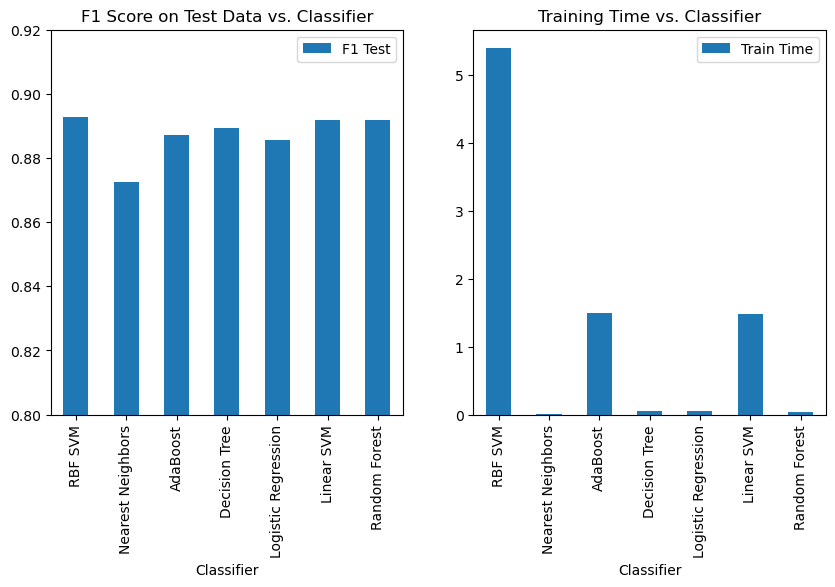

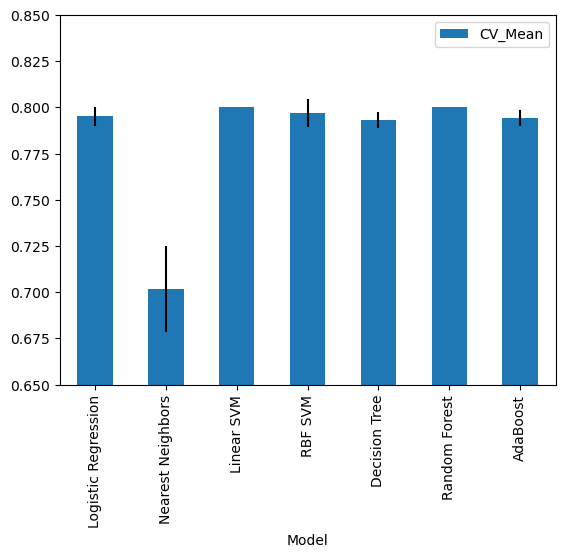

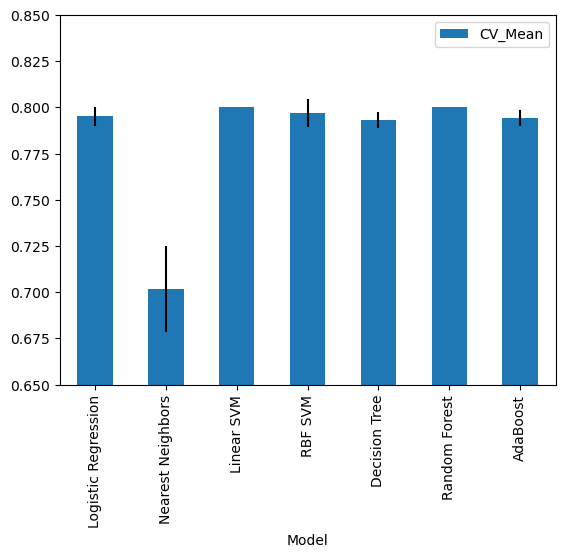

In [16]:
# Plot the mean cross-validation scores with error bars representing the standard deviation
# Set the y-axis to represent the mean cross-validation scores
# Set the error bars to represent the standard deviation of the cross-validation scores
# Limit the y-axis to the range [0.65, 0.85] for better visualization
cv.plot(y='CV_Mean', yerr='CV_Std_Dev', kind='bar', ylim=[0.65, 0.85])
plt.show()